# PDMS Brushes

# Libraries

In [234]:
%run ../../../setup_workspace.py # ../ means level up 

✓ Workspace ready


In [22]:
import matplotlib
from matplotlib.ticker import ScalarFormatter
from scipy.special import voigt_profile

# Data

In [3]:
Exp_M11 = BM26_experiment(r"E:\Li Heng Brushes\ihsc1916\20251129\RAW_DATA\Bott_PDMS_bis\Bott_PDMS_bis_M11_PDNS_Melt")
Exp_NG2 = BM26_experiment(r"E:\Li Heng Brushes\ihsc1916\20251129\RAW_DATA\Bott_PDMS_bis\Bott_PDMS_bis_PDMS_BNMA_NG2_Melt")
Exp_NG3 = BM26_experiment(r"E:\Li Heng Brushes\ihsc1916\20251129\RAW_DATA\Bott_PDMS_bis\Bott_PDMS_bis_PDMS_BNMA_NG3_melt")
Exp_NG4 = BM26_experiment(r"E:\Li Heng Brushes\ihsc1916\20251129\RAW_DATA\Bott_PDMS_bis\Bott_PDMS_bis_PDMS_BNMA_NG4_melt")
Exp_NG7 = BM26_experiment(r"E:\Li Heng Brushes\ihsc1916\20251129\RAW_DATA\Bott_PDMS_bis\Bott_PDMS_bis_PDMS_BNMA_NG7_melt_15perc_Conversion")

Exp_empty = BM26_experiment(r"E:\Li Heng Brushes\ihsc1916\20251129\RAW_DATA\Bott_PDMS_bis\Bott_PDMS_bis_Empty_Linkam_bis")

Found 10 EDF files in SAXS
Found 10 EDF files in SAXS
Found 10 EDF files in SAXS


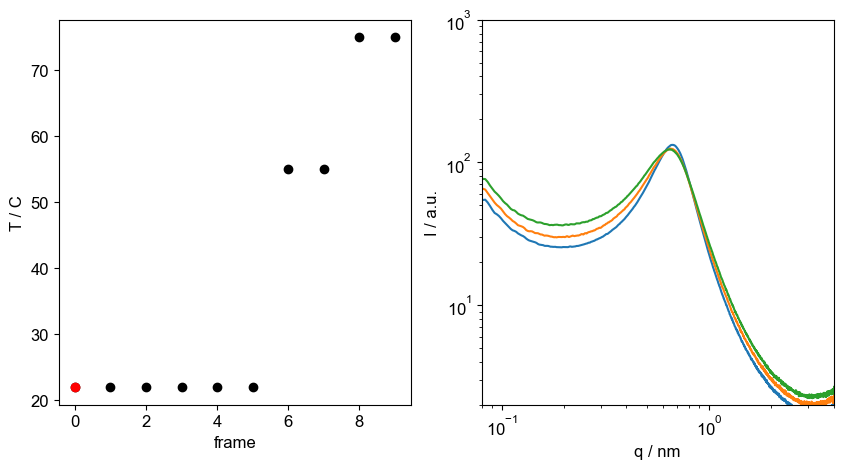

In [345]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 5))
Exp = Exp_NG7
frame = 0

ax1.scatter(range(len(Exp.get_T_profile())),Exp.get_T_profile(),  color='black')
ax1.scatter(frame, Exp.get_T_profile()[frame], color='red', zorder=10)
ax1.set_xlabel('frame')
ax1.set_ylabel('T / C')

q, I = Exp.get_1d_SAXS(frame)
#ax2.plot(q, I, color='black')
ax2.set_xlabel('q / nm')
ax2.set_ylabel('I / a.u.')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.08, 4)
ax2.set_ylim(2, 1e3)

# q, I_average = Exp.get_1d_SAXS(frame)
# ax2.plot(q, I_average)

q, I_average = Exp.average_1d(range(6 ))
Tr = np.mean(Exp.get_Tr_profile()[:6])
ax2.plot(q, I_average / Tr - I_empty * Tr_empty * 0.9, label='22 C')


q, I_average = Exp.average_1d(range(6, 8 ))
Tr = np.mean(Exp.get_Tr_profile()[6:8])
ax2.plot(q, I_average / Tr - I_empty * Tr_empty * 0.9, label='22 C')

q, I_average = Exp.average_1d(range(8, 10))
Tr = np.mean(Exp.get_Tr_profile()[8:])
ax2.plot(q, I_average / Tr - I_empty * Tr_empty * 0.9, label='75 C')


# q, I_average = Exp.average_1d(range(11, 13 ))
# ax2.plot(q, I_average * 1.5 )

# q, I_average = Exp.average_1d(range(13, 15 ))
# ax2.plot(q, I_average * 2.5)

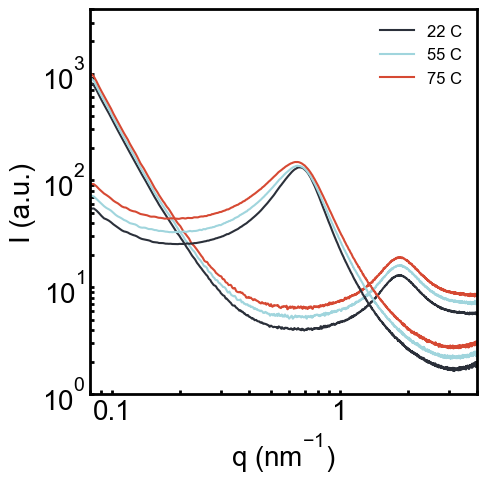

In [353]:
# Figure settings
linewidth = 3

# Set font to Arial for all text
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

Exp = Exp_empty
q, I_empty = Exp.get_1d_SAXS()
#
Tr_empty = Exp.get_Tr_profile()[0]

Exp = Exp_M11
q, I_average = Exp.average_1d(range(1, 10 ))
Tr = np.mean(Exp.get_Tr_profile()[1:10])
ax.plot(q, I_average / Tr - I_empty * Tr_empty * 0.9, label='22 C', color='#2B303A')


q, I_average = Exp.average_1d(range(11, 13 ))
Tr = np.mean(Exp.get_Tr_profile()[11:13])
ax.plot(q, (I_average / Tr - I_empty * Tr_empty * 0.9)*1.1, label='55 C', color='#A0D5DD')

q, I_average = Exp.average_1d(range(13, 15))
Tr = np.mean(Exp.get_Tr_profile()[13:])
ax.plot(q, (I_average / Tr - I_empty * Tr_empty * 0.9)*1.21, label='75 C', color='#D64933')

Exp = Exp_NG7
q, I_average = Exp.average_1d(range(6 ))
Tr = np.mean(Exp.get_Tr_profile()[:6])
ax.plot(q, I_average / Tr - I_empty * Tr_empty * 0.9, color='#2B303A')


q, I_average = Exp.average_1d(range(6, 8 ))
Tr = np.mean(Exp.get_Tr_profile()[6:8])
ax.plot(q,( I_average / Tr - I_empty * Tr_empty * 0.9) * 1.1, color='#A0D5DD')

q, I_average = Exp.average_1d(range(8, 10))
Tr = np.mean(Exp.get_Tr_profile()[8:])
ax.plot(q, (I_average / Tr - I_empty * Tr_empty * 0.9) * 1.21, color='#D64933')



ax.set_xlim(0.08, 4)
ax.set_ylim(1, 4e3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.set_xticks([0.1, 1, 2])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=2, length=3)

# Labels - use text instead of ma     th mode
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

ax.set_xscale('log')
ax.set_yscale('log')

# Set decimal format for x-axis ticks without trailing zeros
ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%g'))

# Set Arial font for tick labels
ax.tick_params(axis='both', which='major', labelsize=20)
for tick in ax.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontname('Arial')
    
plt.legend(frameon=False, fontsize=12)

# Functions

In [306]:
def Voigt_power(x, A, m, sigma, gamma, I_p, p):
    return A * voigt_profile(x - m, sigma, gamma) + I_p * x ** -p

def Voigt(x, A, m, sigma, gamma):
    return A * voigt_profile(x - m, sigma, gamma) 
    
def power(x, I_p, p):
    return I_p * x ** -p

def lin_interp(x, y, i, half):
    return x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i]))

def half_max_x(x, y):
    half = max(y)/2.0
    signs = np.sign(np.add(y, -half))
    zero_crossings = (signs[0:-2] != signs[1:-1])
    zero_crossings_i = np.where(zero_crossings)[0]
    return [lin_interp(x, y, zero_crossings_i[0], half),
            lin_interp(x, y, zero_crossings_i[1], half)]

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

def log_norm_power(x,I0, q0, s, I_p, p):
    return  log_normal_peak(x, I0, q0, s) + I_p * x ** -p

# Analysis

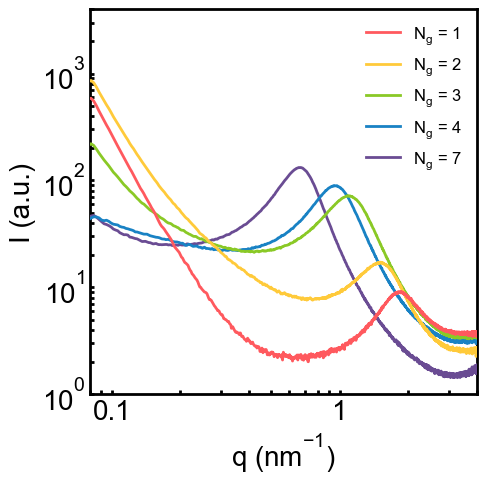

In [238]:
# Figure settings
linewidth = 3

# Set font to Arial for all text
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

Exp = Exp_empty
q, I_empty = Exp.get_1d_SAXS()
#
Tr_empty = Exp.get_Tr_profile()[0]

Exp = Exp_M11
q, I = Exp.get_1d_SAXS(10)
Tr = Exp.get_Tr_profile()[0]
ax.plot(q, I / Tr - I_empty * Tr_empty, color='#ff595e', linewidth=2, label='N$_{g}$ = 1', zorder=10)

Exp = Exp_NG2
q, I = Exp.average_1d(range(6 ))
Tr = Exp.get_Tr_profile()[0]
Exp = Exp_NG2
q, I = Exp.get_1d_SAXS()
Tr = Exp.get_Tr_profile()[0]
ax.plot(q, I / Tr - I_empty * Tr_empty, color='#ffca3a', linewidth=2,  label='N$_{g}$ = 2', zorder=9)

Exp = Exp_NG3
q, I = Exp.get_1d_SAXS()
Tr = Exp.get_Tr_profile()[0]
ax.plot(q, I / Tr - I_empty * Tr_empty, color='#8ac926', linewidth=2, label='N$_{g}$ = 3', zorder=8)

Exp = Exp_NG4
q, I = Exp.get_1d_SAXS()
Tr = Exp.get_Tr_profile()[0]
ax.plot(q, I / Tr - I_empty * Tr_empty * 0.8, color='#1982c4', linewidth=2, label='N$_{g}$ = 4', zorder=7)

Exp = Exp_NG7
q, I = Exp.get_1d_SAXS()
Tr = Exp.get_Tr_profile()[0]
ax.plot(q, I / Tr - I_empty * Tr_empty, color='#6a4c93', linewidth=2, label='N$_{g}$ = 7', zorder=5)

ax.set_xlim(0.08, 4)
ax.set_ylim(1, 4e3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.set_xticks([0.1, 1, 2])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=2, length=3)

# Labels - use text instead of math mode
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

ax.set_xscale('log')
ax.set_yscale('log')

# Set decimal format for x-axis ticks without trailing zeros
ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%g'))

# Set Arial font for tick labels
ax.tick_params(axis='both', which='major', labelsize=20)
for tick in ax.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontname('Arial')
    
plt.legend(frameon=False, fontsize=12)

3.4220749916520288


IndexError: index 1 is out of bounds for axis 0 with size 1

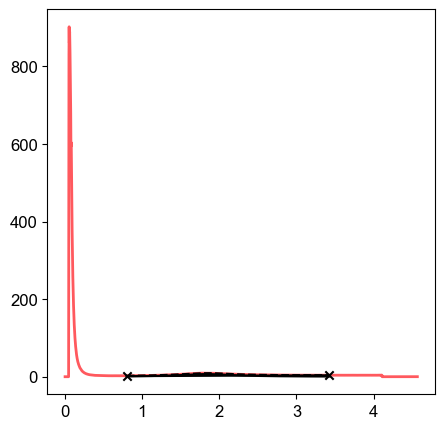

In [244]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

Exp = Exp_empty
q, I_empty = Exp.get_1d_SAXS()
#
Tr_empty = Exp.get_Tr_profile()[0] * 0.9

Exp = Exp_M11
q, I = Exp.average_1d(range(1, 10 ))
Tr = Exp.get_Tr_profile()[0]
I_sub = I / Tr - I_empty * Tr_empty
ax.plot(q, I_sub, color='#ff595e', linewidth=2, label='N$_{g}$ = 1', zorder=10)
pd.DataFrame({'q':q, 'I':I_sub}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_M11_sub.txt', sep=str('\t'), index=False)

l, r = 350, 1500
plt.scatter([q[l], q[r]], [I_sub[l], I_sub[r]], zorder=10, color='black', marker='x')

p, cov = curve_fit(Voigt_power, q[l:r], I_sub[l:r], p0=[3, 1.8, 1, 0, 1, -1])
plt.plot(q[l:r], Voigt_power(q[l:r], *p), color='black', linestyle='--', zorder=10)
plt.plot(q[l:r], power(q[l:r], *p[-2:]), color='black',  zorder=10)
pd.DataFrame({'q':q[l:r], 'I':power(q[l:r], *p[-2:])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_M11_power.txt', sep=str('\t'), index=False)
plt.plot(q[l:r], Voigt(q[l:r], *p[:-2]), color='black',  zorder=10)
pd.DataFrame({'q':q, 'I':Voigt(q, *p[:-2])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_M11_peak.txt', sep=str('\t'), index=False)
print(2*np.pi/p[1])
peak = Voigt(lnsp, *p[:4])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

Exp = Exp_NG2
q, I = Exp.average_1d(range(6))
Tr = Exp.get_Tr_profile()[0]
I_sub = I / Tr - I_empty * Tr_empty
ax.plot(q, I_sub, color='#ffca3a', linewidth=2, label='N$_{g}$ = 2', zorder=10)
pd.DataFrame({'q':q, 'I':I_sub}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG2_sub.txt', sep=str('\t'), index=False)

l, r = 300, 1500
plt.scatter([q[l], q[r]], [I_sub[l], I_sub[r]], zorder=10, color='black', marker='x')

p, cov = curve_fit(Voigt_power, q[l:r], I_sub[l:r], p0=[3, 1.8, 1, 0, 1, -1])
plt.plot(q[l:r], Voigt_power(q[l:r], *p), color='black', linestyle='--', zorder=10)
plt.plot(q[l:r], power(q[l:r], *p[-2:]), color='black',  zorder=10)
pd.DataFrame({'q':q[l:r], 'I':power(q[l:r], *p[-2:])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG2_power.txt', sep=str('\t'), index=False)
plt.plot(q[l:r], Voigt(q[l:r], *p[:-2]), color='black',  zorder=10)
pd.DataFrame({'q':q, 'I':Voigt(q, *p[:-2])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG2_peak.txt', sep=str('\t'), index=False)
print(2*np.pi/p[1])
peak = Voigt(lnsp, *p[:4])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

Exp = Exp_NG3
q, I = Exp.average_1d(range(7 ))
Tr = Exp.get_Tr_profile()[0]
I_sub = I / Tr - I_empty * Tr_empty
ax.plot(q, I_sub, color='#8ac926', linewidth=2, label='N$_{g}$ = 3', zorder=10)
pd.DataFrame({'q':q, 'I':I_sub}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG3_sub.txt', sep=str('\t'), index=False)

l, r = 190, 1200
plt.scatter([q[l], q[r]], [I_sub[l], I_sub[r]], zorder=10, color='black', marker='x')

p, cov = curve_fit(Voigt_power, q[l:r], I_sub[l:r], p0=[3, 1., 1, 0, 1, -1])
plt.plot(q[l:r], Voigt_power(q[l:r], *p), color='black', linestyle='--', zorder=10)
plt.plot(q[l:r], power(q[l:r], *p[-2:]), color='black',  zorder=10)
pd.DataFrame({'q':q[l:r], 'I':power(q[l:r], *p[-2:])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG3_power.txt', sep=str('\t'), index=False)
plt.plot(q[l:r], Voigt(q[l:r], *p[:-2]), color='black',  zorder=10)
pd.DataFrame({'q':q, 'I':Voigt(q, *p[:-2])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG3_peak.txt', sep=str('\t'), index=False)
print(2*np.pi/p[1])
peak = Voigt(lnsp, *p[:4])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

Exp = Exp_NG4
q, I = Exp.average_1d(range(5 ))
Tr = Exp.get_Tr_profile()[0]
I_sub = I / Tr - I_empty * Tr_empty
ax.plot(q, I_sub, color='#1982c4', linewidth=2, label='N$_{g}$ = 4', zorder=10)
pd.DataFrame({'q':q, 'I':I_sub}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG4_sub.txt', sep=str('\t'), index=False)

l, r = 170, 1100
plt.scatter([q[l], q[r]], [I_sub[l], I_sub[r]], zorder=10, color='black', marker='x')

p, cov = curve_fit(Voigt_power, q[l:r], I_sub[l:r], p0=[3, 1., 1, 0, 1, -1])
plt.plot(q[l:r], Voigt_power(q[l:r], *p), color='black', linestyle='--', zorder=10)
plt.plot(q[l:r], power(q[l:r], *p[-2:]), color='black',  zorder=10)
pd.DataFrame({'q':q[l:r], 'I':power(q[l:r], *p[-2:])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG4_power.txt', sep=str('\t'), index=False)
plt.plot(q[l:r], Voigt(q[l:r], *p[:-2]), color='black',  zorder=10)
pd.DataFrame({'q':q, 'I':Voigt(q, *p[:-2])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG4_peak.txt', sep=str('\t'), index=False)
print(2*np.pi/p[1])
peak = Voigt(lnsp, *p[:4])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

Exp = Exp_NG7
q, I = Exp.average_1d(range(5 ))
Tr = Exp.get_Tr_profile()[0]
I_sub = I / Tr - I_empty * Tr_empty
ax.plot(q, I_sub, color='#6a4c93', linewidth=2, label='N$_{g}$ = 7', zorder=10)
pd.DataFrame({'q':q, 'I':I_sub}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG7_sub.txt', sep=str('\t'), index=False)

l, r = 80, 800
plt.scatter([q[l], q[r]], [I_sub[l], I_sub[r]], zorder=10, color='black', marker='x')

p, cov = curve_fit(Voigt_power, q[l:r], I_sub[l:r], p0=[3, .7, 1, 0, 1, -1])
plt.plot(q[l:r], Voigt_power(q[l:r], *p), color='black', linestyle='--', zorder=10)
plt.plot(q[l:r], power(q[l:r], *p[-2:]), color='black',  zorder=10)
pd.DataFrame({'q':q[l:r], 'I':power(q[l:r], *p[-2:])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG7_power.txt', sep=str('\t'), index=False)
plt.plot(q[l:r], Voigt(q[l:r], *p[:-2]), color='black',  zorder=10)
pd.DataFrame({'q':q, 'I':Voigt(q, *p[:-2])}).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Exp_NG7_peak.txt', sep=str('\t'), index=False)
print(2*np.pi/p[1])
peak = Voigt(lnsp, *p[:4])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))

ax.set_xlim(0.08, 4)
ax.set_ylim(1, 4e3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.set_xticks([0.1, 1, 2])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=2, length=3)

# Labels - use text instead of math mode
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

ax.set_xscale('log')
ax.set_yscale('log')

# Set decimal format for x-axis ticks without trailing zeros
ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%g'))

# Set Arial font for tick labels
ax.tick_params(axis='both', which='major', labelsize=20)
for tick in ax.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontname('Arial')
    
plt.legend(frameon=False, fontsize=12)

1.869640487900126
3.419160554249301


[]

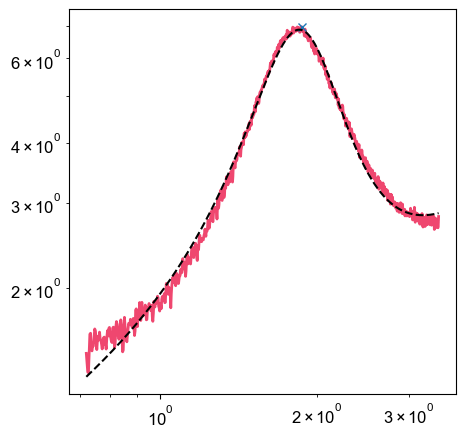

In [241]:
Exp = Exp_NG2
q, I = Exp_M11.get_1d_SAXS(10)
Tr = Exp.get_Tr_profile()[10]
I_sub = I / Tr - I_empty * Tr_empty

plt.figure(figsize=(5,5))

l, r = 315, 1500

plt.plot(q[l:r], I_sub[l:r], color='#ef476f', linewidth=2, zorder=10, label='N$_{g}$ = 2')
#plt.scatter([q[l], q[r]], [I_sub[l], I_sub[r]], zorder=10, color='black', marker='x')

print(q[l:r][np.argmax(I_sub[l:r])])
plt.plot(q[l:r][np.argmax(I_sub[l:r])], I_sub[l:r][np.argmax(I_sub[l:r])], marker='x', zorder=10)

p, cov = curve_fit(Voigt_power, q[l:r], I_sub[l:r], p0=[3, 1.8, 1, 0, 1, -1])
plt.plot(q[l:r], Voigt_power(q[l:r], *p), color='black', linestyle='--', zorder=10)

print(2*np.pi/p[1])
plt.semilogx()
plt.semilogy()

In [245]:
p

array([ 9.18946810e+00,  1.83607470e+00,  4.19032261e-05,  4.27428908e-01,
        1.55489548e+00, -6.79927728e-01])

np.float64(0.8548698989174148)

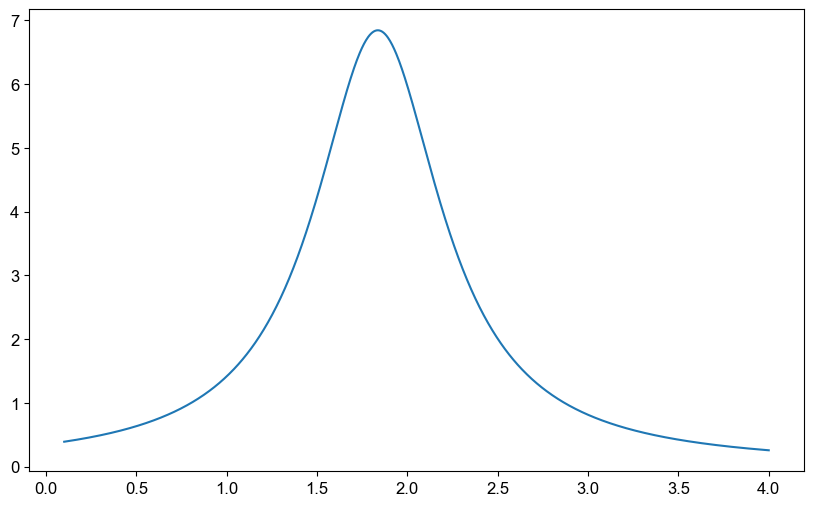

In [246]:
lnsp = np.linspace(0.1, 4, 1000)
peak = Voigt(lnsp, *p[:4])
plt.plot(lnsp, peak)

peak = Voigt(lnsp, *p[:4])
half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]

# Li Heng Brushes


6.276638687345554
0.5406313424496118
10.459746471300221

5.189616935462184
0.6233617056859053
9.071565874004712

4.607583485800287
0.6575496930710609
8.599907864074556

4.086367076206781
0.7815469701704829
7.235479110395761

3.7546533485302582
0.752912602534836
7.510654965029604

3.7774650039905286
0.7299309575774184
7.747125557230332

3.6436929046072164
0.7027016942652944
8.047321961239954

3.365170911392635
0.6488342160028526
8.71542627837735



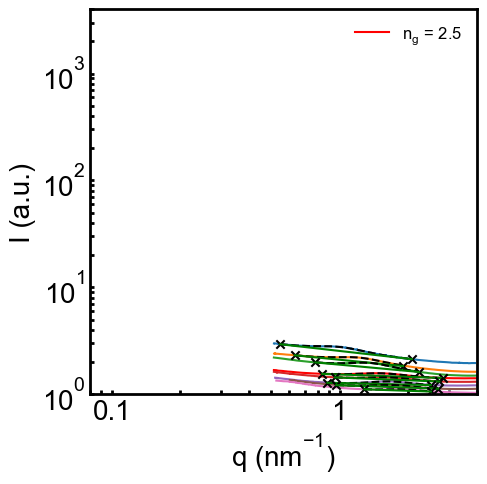

In [326]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))


df1 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\1.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df1['q'], np.exp(df1['I']) * 1.1
l, r = 3, 70
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1,  0.4, 8.14702353e-01, -9.06943565e-01], 
                   maxfev = 5000, 
                   #sigma=y[l:r]
                  )

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

df2 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\2.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df2['q'], np.exp(df2['I'])
l, r = 10, 70
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1.2,  0.2, 8.14702353e-01, -9.06943565e-01],
                   maxfev = 5000, 
                   sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()


df3 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\3.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df3['q'], np.exp(df3['I'])
l, r = 20, 80
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1.5,  0.2, 8.14702353e-01, -9.06943565e-01], 
                   maxfev = 5000, sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

df4 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\4.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df4['q'], np.exp(df4['I'])
l, r = 20, 55
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y,  color='red', label='n$_{g}$ = 2.5',)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1.7,  0.2,   8.14702353e-01, -9.06943565e-01], 
                   maxfev = 5000, sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()

df5 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\5.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df5['q'], np.exp(df5['I'])
l, r = 30, 60
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1.5,  0.2,  8.14702353e-01, -9.06943565e-01], 
                   maxfev = 5000, sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()


df6 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\6.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df6['q'], np.exp(df6['I'])
l, r = 25, 55
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1.7,  0.2, 8.14702353e-01, -9.06943565e-01], 
                   maxfev = 5000, sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()


df7 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\7.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df7['q'], np.exp(df7['I'])
l, r = 20, 50
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)
plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[3, 1.8,  0.2, 8.14702353e-01, -9.06943565e-01], 
                   maxfev = 5000, sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()


df8 = pd.read_csv(r"E:\Li Heng Brushes\Data_for_plots\Visualized\8.csv", sep=';', names=['q', 'I'], decimal=',')
x, y = df8['q'], np.exp(df8['I'])
l, r = 38, 55
lnsp = np.linspace(x[l], x[r], 1000)
plt.plot(x, y)

plt.scatter([x[l], x[r]], [y[l], y[r]], zorder=10, color='black', marker='x')
p, cov = curve_fit(log_norm_power, x[l:r], y[l:r], 
                   p0=[ 1.95947713e-02, 1.8, 0.2, 1.20973793e+00, 1.68985370e-02], 
                   maxfev = 10000, sigma=y[l:r])

plt.plot(lnsp, log_norm_power(lnsp, *p), linestyle='--', color='black', zorder=10)
plt.plot(lnsp, power(lnsp, *p[-2:]),  color='green', zorder=10)
# plt.plot(lnsp, Voigt(lnsp, *p[:-2]), color='black', zorder=10)
lnsp =  np.linspace(x[l]*0.5, x[r]*2, 1000)
print(2 * np.pi / p[1])
peak = log_normal_peak(lnsp, *p[:3])
print(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0])
print(0.9*2*np.pi/(half_max_x(lnsp, peak)[1] - half_max_x(lnsp, peak)[0]))
print()


ax.set_xlim(0.08, 4)
ax.set_ylim(1, 4e3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.set_xticks([0.1, 1, 2])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=2, length=3)

# Labels - use text instead of math mode
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

ax.set_xscale('log')
ax.set_yscale('log')

# Set decimal format for x-axis ticks without trailing zeros
ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%g'))

# Set Arial font for tick labels
ax.tick_params(axis='both', which='major', labelsize=20)
for tick in ax.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontname('Arial')
    
plt.legend(frameon=False, fontsize=12)

In [301]:
pd.DataFrame({'q1':df1['q'], 'I1':np.exp(df1['I']),
              'q2':df2['q'], 'I2':np.exp(df2['I']),
              'q3':df3['q'], 'I3':np.exp(df3['I']),
              'q4':df4['q'], 'I4':np.exp(df4['I']),
              'q5':df5['q'], 'I5':np.exp(df5['I']),
              'q6':df6['q'], 'I6':np.exp(df6['I']),
              'q7':df7['q'], 'I7':np.exp(df7['I']),
              'q8':df8['q'], 'I8':np.exp(df8['I']),
             }).to_csv(r'E:\Li Heng Brushes\Data_for_plots\Visualized\all.txt', sep=str('\t'), index=False)